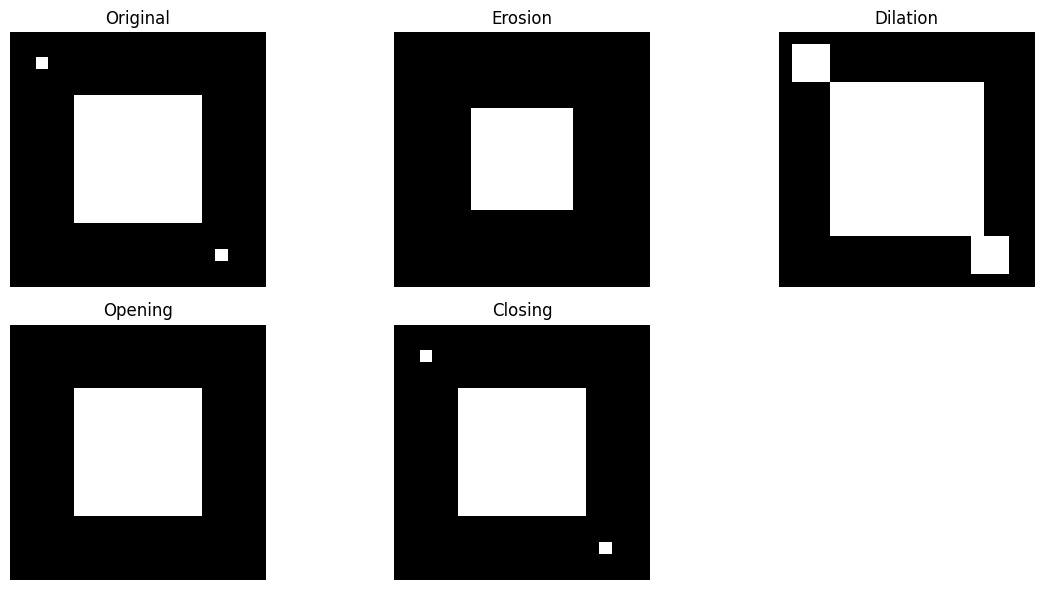

In [16]:
# Starter template

student_img = np.zeros((20, 20), dtype=np.uint8)

# Example object
student_img[5:15, 5:15] = 1

# Add noise
student_img[2, 2] = 1
student_img[17, 16] = 1

student_kernel = np.ones((3, 3), dtype=np.uint8)

student_eroded = cv2.erode(student_img, student_kernel, iterations=1)
student_dilated = cv2.dilate(student_img, student_kernel, iterations=1)
student_opened = cv2.morphologyEx(student_img, cv2.MORPH_OPEN, student_kernel)
student_closed = cv2.morphologyEx(student_img, cv2.MORPH_CLOSE, student_kernel)

plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(student_img, cmap='gray', vmin=0, vmax=1)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(student_eroded, cmap='gray', vmin=0, vmax=1)
plt.title("Erosion")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(student_dilated, cmap='gray', vmin=0, vmax=1)
plt.title("Dilation")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(student_opened, cmap='gray', vmin=0, vmax=1)
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(student_closed, cmap='gray', vmin=0, vmax=1)
plt.title("Closing")
plt.axis("off")

plt.tight_layout()
plt.show()


In [1]:
from google.colab import files
uploaded = files.upload()

Saving finger.png to finger.png


In [2]:
from google.colab import files
uploaded = files.upload()

Saving text.png to text.png


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def show(title, img, cmap='gray'):
    plt.figure(figsize=(5,5))
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')

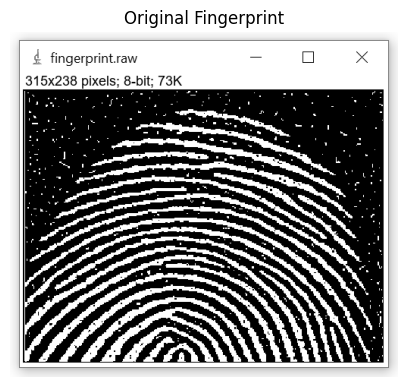

In [5]:
finger = cv2.imread('finger.png', cv2.IMREAD_GRAYSCALE)
show("Original Fingerprint", finger)

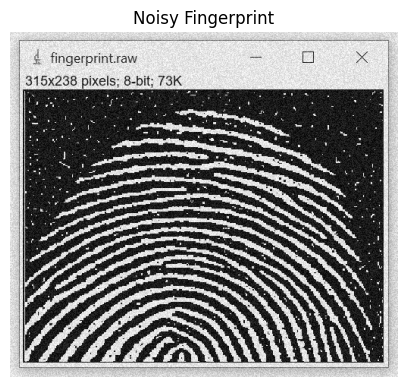

In [6]:
noise = np.random.randint(0, 256, finger.shape, dtype=np.uint8)
noisy_finger = cv2.addWeighted(finger, 0.8, noise, 0.2, 0)

show("Noisy Fingerprint", noisy_finger)

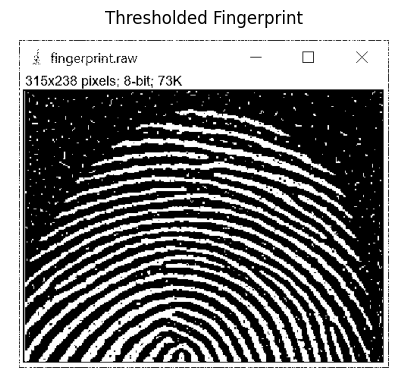

In [7]:
_, thresh_finger = cv2.threshold(noisy_finger, 127, 255, cv2.THRESH_BINARY)
show("Thresholded Fingerprint", thresh_finger)

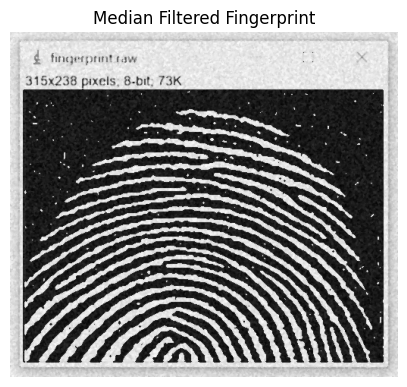

In [8]:
median_finger = cv2.medianBlur(noisy_finger, 3)
show("Median Filtered Fingerprint", median_finger)

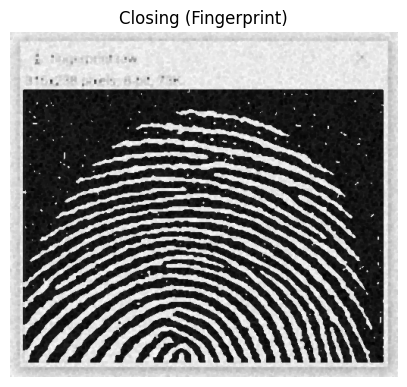

In [9]:
kernel = np.ones((3,3), np.uint8)

closing_finger = cv2.morphologyEx(median_finger, cv2.MORPH_CLOSE, kernel)
show("Closing (Fingerprint)", closing_finger)

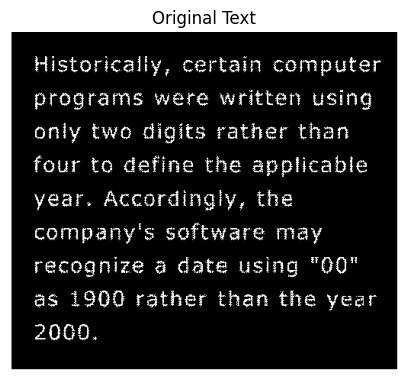

In [10]:
text = cv2.imread('text.png', cv2.IMREAD_GRAYSCALE)
show("Original Text", text)

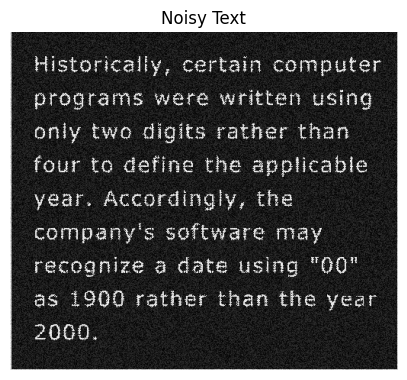

In [11]:
noise = np.random.randint(0, 256, text.shape, dtype=np.uint8)
noisy_text = cv2.addWeighted(text, 0.8, noise, 0.2, 0)

show("Noisy Text", noisy_text)

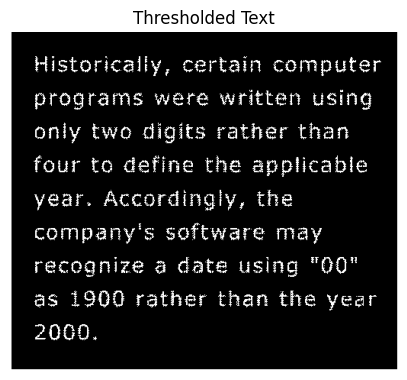

In [12]:
_, thresh_text = cv2.threshold(noisy_text, 127, 255, cv2.THRESH_BINARY)
show("Thresholded Text", thresh_text)

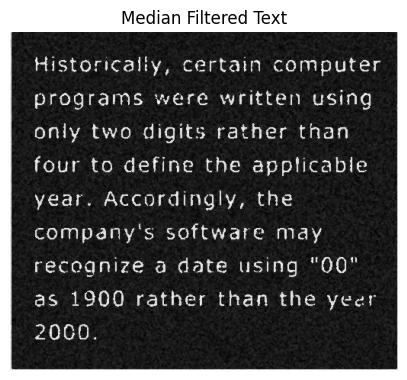

In [13]:
median_text = cv2.medianBlur(noisy_text, 3)
show("Median Filtered Text", median_text)

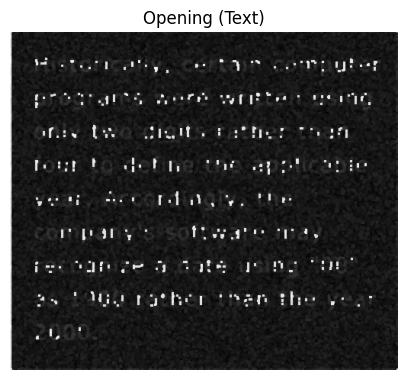

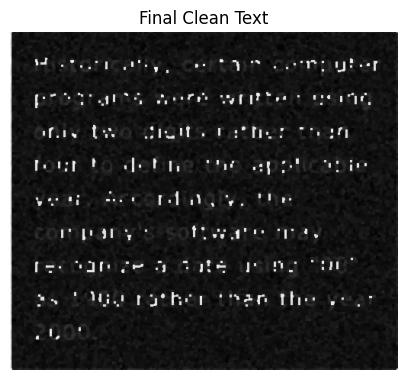

In [14]:
opening_text = cv2.morphologyEx(median_text, cv2.MORPH_OPEN, kernel)
show("Opening (Text)", opening_text)

closing_text = cv2.morphologyEx(opening_text, cv2.MORPH_CLOSE, kernel)
show("Final Clean Text", closing_text)

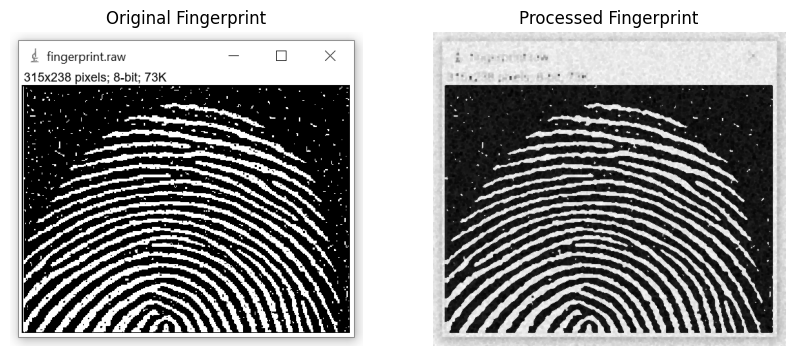

In [15]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Fingerprint")
plt.imshow(finger, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Processed Fingerprint")
plt.imshow(closing_finger, cmap='gray')
plt.axis('off')

plt.show()